# 1.0 Package Import

In [104]:
# pip install tensorflow-macos tensorflow-metal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.0/227.0 MB 3.8 MB/s  0:01:03m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 4.8 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 6.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 5.0 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.32.0
    Uninstalling protobuf-6.32.0:
      Successfully uninstalled protobuf-6.32.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: ml-dtypes━━━━━━━━━━━━━━━━━━━━━━━━ 3/8 [numpy]
    Found existing installation: ml_dtypes 0.5.3━━━━━━━━━━━━━━ 3/8 [numpy]
    Uninstalling ml_dtypes-0.5.3:━━━━━━━━━━━━━━━━━━━━━━━━ 3/8 [numpy]
      Successfully uninstalled ml_dtypes-

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import os
import json
import math

In [2]:
import cv2
import numpy as np
from ultralytics import YOLO
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

/Users/tee/Projects/pj1_car/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import json

In [4]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [5]:
import tensorflow as tf
# print("TensorFlow version:", tf.__version__)
# print("GPUs detected:", tf.config.list_physical_devices('GPU'))

In [6]:
from tensorflow.keras import mixed_precision
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import AdamW

# 2.0 Dataset Inspection

In [7]:
# dataset path
ROOT = Path("../../data/car_colour/dataset").resolve()  
SPLITS = ["train", "val","test"]  
OUTPUT_DIR = Path("../../data/car_colour/output").resolve()
IMAGE_EXTS = {".jpg"}

In [8]:
# Count files per color for each split
split_counts = {}  # split -> Counter(color -> count)
all_colors = set()

for split in SPLITS:
    split_dir = ROOT / split
    if not split_dir.exists():
        print(f"[WARN] Missing split folder: {split_dir}")
        split_counts[split] = Counter()
        continue

    counts = Counter()
    for color_dir in sorted([d for d in split_dir.iterdir() if d.is_dir()]):
        color = color_dir.name
        n = sum(1 for p in color_dir.iterdir()
                if p.is_file() and p.suffix.lower() in IMAGE_EXTS and not p.name.startswith('.'))
        counts[color] += n
        all_colors.add(color)

    split_counts[split] = counts

In [9]:
all_colors = sorted(all_colors)
for split in SPLITS:
    for c in all_colors:
        split_counts.setdefault(split, Counter())
        split_counts[split].setdefault(c, 0)

In [10]:
# summary table
print("\nImage counts per color:")
header = ["split"] + all_colors + ["TOTAL"]
row_sep = "-" * (8 + 10 * (len(all_colors) + 1))
print(row_sep)
print("{:<8}".format("split"), end="")
for c in all_colors:
    print("{:>9}".format(c[:9]), end=" ")
print("{:>9}".format("TOTAL"))
print(row_sep)

for split in SPLITS:
    total = sum(split_counts[split].values())
    print(f"{split:<8}: {total} images")
    for c in all_colors:
        print("{:>9}".format(split_counts[split][c]), end=" ")
    print("{:>9}".format(total))
print(row_sep)


Image counts per color:
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
split       beige     black      blue     brown      gold     green      grey    orange      pink    purple       red    silver       tan     white    yellow     TOTAL
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
train   : 7267 images
      421       406       742       565       210       563       428       534       483       536       637       362       400       403       577      7267
val     : 1550 images
       90        86       159       121        45       120        91       114       103       114       136        77        85        86       123      1550
test    : 1556 images
       90        87       159       121        45       121        92       114    

In [11]:
### Consider if the dataset will be class imbalance

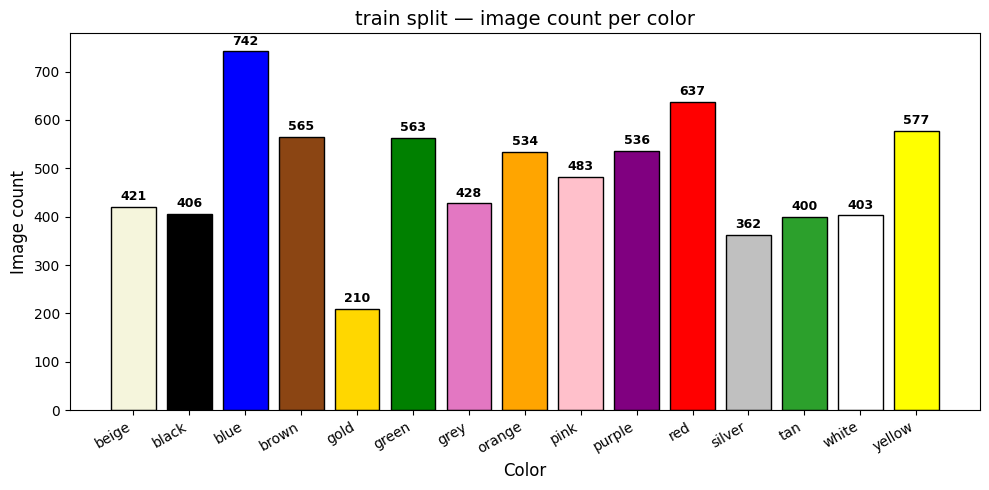

[Saved] /Users/tee/Projects/pj1_car/data/car_colour/output/train_color_counts.png


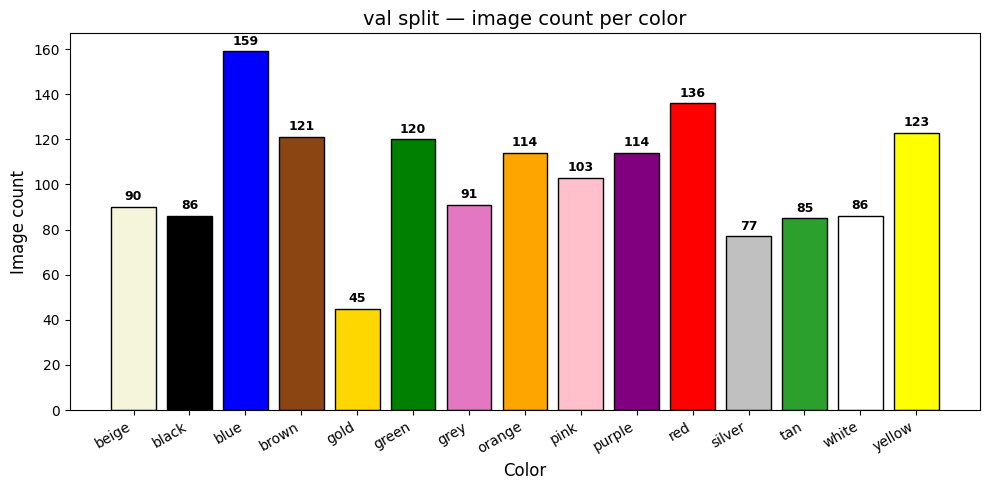

[Saved] /Users/tee/Projects/pj1_car/data/car_colour/output/val_color_counts.png


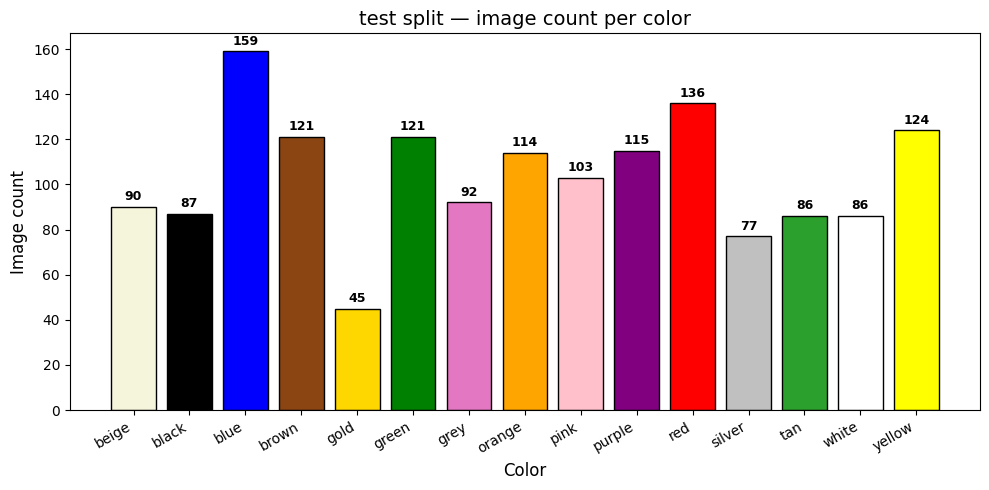

[Saved] /Users/tee/Projects/pj1_car/data/car_colour/output/test_color_counts.png


In [12]:
# plot
COLOR_MAP = {
    "red": "red",
    "blue": "blue",
    "green": "green",
    "yellow": "yellow",
    "orange": "orange",
    "black": "black",
    "white": "white",
    "gray": "gray",
    "silver": "silver",
    "brown": "saddlebrown",
    "purple": "purple",
    "pink": "pink",
    "gold": "gold",
    "beige": "beige",
    "maroon": "maroon",
}

# count
for split in SPLITS:
    counts = [split_counts[split][c] for c in all_colors]
    
    # match bar colour
    bar_colors = [
        COLOR_MAP.get(c.lower(), mcolors.TABLEAU_COLORS[list(mcolors.TABLEAU_COLORS)[i % 10]])
        for i, c in enumerate(all_colors)
    ]
    
    plt.figure(figsize=(10, 5))
    bars = plt.bar(all_colors, counts, color=bar_colors, edgecolor="black")

    # add value labels
    for bar, count in zip(bars, counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts) * 0.01,
            str(count),
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    plt.title(f"{split} split — image count per color", fontsize=14)
    plt.xlabel("Color", fontsize=12)
    plt.ylabel("Image count", fontsize=12)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    out_path = OUTPUT_DIR / f"{split}_color_counts.png"
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"[Saved] {out_path}")

# 3.0 Model Training

## 3.1 Config

In [13]:
# folder to take out windows tyres etc
PROC_DIR = OUTPUT_DIR / "processed"                
PROC_DIR.mkdir(parents=True, exist_ok=True)

In [14]:
# YOLO seg weights (can be fine-tuned further later) 
YOLO_WEIGHTS = "yolo11n-seg.pt"  
YOLO_CONF = 0.25        # confidence threshold
YOLO_IOU = 0.5          # NMS IoU threshold

# image setting
TARGET_SIZE = (128, 128) #performance didn't improve when changing size to 224

# Training settings
BATCH_SIZE = 32
EPOCHS = 100           # check if need to change it back to 25
LEARNING_RATE = 5e-5  # check if need to change it back to 5e-5/5e-4/1e-4

In [15]:
# Yolo model
yolo_model = YOLO(YOLO_WEIGHTS)

## 3.2 Preprocess dataset

In [16]:
# Run YOLO-seg on an image (BGR np.uint8 HxWx3), return a binary mask (HxW) for the
# Best 'car' instance, or None if not found.
# Below script passes BGR and rely on internal conversions; alternatively convert to RGB.

def get_best_car_mask(img_bgr):
    results = yolo_model.predict(
        source=img_bgr,
        verbose=False,
        conf=YOLO_CONF,
        iou=YOLO_IOU
    )
    if not results or len(results) == 0:
        return None

    r = results[0]
    if r.masks is None or r.boxes is None:
        return None

    names = r.names  # dict: id -> name
    car_ids = [i for i, n in names.items() if n.lower() in ("car", "automobile")]
    if not car_ids:
        car_ids = list(set(int(b.cls) for b in r.boxes))

    # Select highest confidence car mask
    best_idx = -1
    best_score = -1.0
    for i, box in enumerate(r.boxes):
        cls_id = int(box.cls.item())
        if cls_id in car_ids:
            score = float(box.conf.item())
            if score > best_score:
                best_score = score
                best_idx = i

    if best_idx < 0:
        return None

    # Binary mask data: (N, mask_h, mask_w), usually already aligned to original shape
    m = r.masks.data[best_idx].cpu().numpy().astype(np.uint8)  # 0/1
    # Ensure size == image size
    h, w = img_bgr.shape[:2]
    mask = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
    mask = (mask > 0).astype(np.uint8)
    return mask

In [17]:
# Heuristics in LAB/HSV to keep car body only pixels (remove windows/tyres/speculars/sky-reflections.)
def refine_body_mask(img_bgr, car_mask):
    h, w = img_bgr.shape[:2]
    keep = car_mask.astype(bool)

    # Convert to LAB
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    L = lab[..., 0]
    a = lab[..., 1] - 128.0
    b = lab[..., 2] - 128.0
    C = np.sqrt(a*a + b*b)

    # 1. Drop very dark (tyres/shadows) and very bright (speculars)
    dark = (L < 25)
    bright = (L > 95)  # CHANGED from 97
    keep &= ~(dark | bright)

    # 2. Drop blue-ish high-L (sky reflection on bonnet/roof)
    sky_like = (L > 70) & (b < -2) & (a > -5) & (a < 15)
    keep &= ~sky_like

    # 3. Keep moderate chroma (glass is often low-chroma; tyres are near-black)
    keep &= (C > 6)    # CHANGED from 4 

    # Morphological open to clean specks
    keep_u8 = keep.astype(np.uint8) * 255
    kernel = np.ones((3, 3), np.uint8)
    keep_u8 = cv2.morphologyEx(keep_u8, cv2.MORPH_OPEN, kernel, iterations=1)

    return (keep_u8 > 0).astype(np.uint8)

In [38]:
# skip mask to test
def process_and_save(img_path, out_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return False
    # skip segmentation for now
    processed = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(out_path), processed, [cv2.IMWRITE_JPEG_QUALITY, 95])
    return True

In [18]:
# # Process & save images to PROC_DIR
# # If no car detected, it fallback to a simple center-crop+resize of the original.
# def process_and_save(img_path, out_path):
#     img = cv2.imread(str(img_path))
#     if img is None:
#         return False

#     car_mask = get_best_car_mask(img)
#     if car_mask is not None:
#         keep_mask = refine_body_mask(img, car_mask)
#         # If mask is too small, fallback
#         if keep_mask.sum() < 0.05 * (img.shape[0] * img.shape[1]):
#             processed = img.copy()
#         else:
#             processed = img.copy()
#             processed[keep_mask == 0] = 0
#     else:
#         # keep original
#         processed = img.copy()

#     # crop around car mask before resize
#     if car_mask is not None and car_mask.sum() > 0:
#         ys, xs = np.where(car_mask > 0)
#         y0, y1 = max(0, ys.min()-5), min(img.shape[0], ys.max()+5)
#         x0, x1 = max(0, xs.min()-5), min(img.shape[1], xs.max()+5)
#         processed = processed[y0:y1, x0:x1]

#     # Resize to model input
#     processed = cv2.resize(processed, TARGET_SIZE, interpolation=cv2.INTER_AREA)

#     out_path.parent.mkdir(parents=True, exist_ok=True)
#     cv2.imwrite(str(out_path), processed, [cv2.IMWRITE_JPEG_QUALITY, 95])
#     return True

In [39]:
print("...Preprocessing images...")
num_ok, num_total = 0, 0
for split in SPLITS:
    split_dir = ROOT / split
    if not split_dir.exists():
        print(f"[WARN] Split not found: {split_dir}")
        continue
    for color_dir in sorted([d for d in split_dir.iterdir() if d.is_dir()]):
        color = color_dir.name
        for p in color_dir.iterdir():
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS and not p.name.startswith('.'):
                num_total += 1
                out_p = PROC_DIR / split / color / (p.stem + ".jpg")
                ok = process_and_save(p, out_p)
                num_ok += int(ok)

print(f"Processed {num_ok}/{num_total} images. Saved to: {PROC_DIR}")

...Preprocessing images...
Processed 10373/10373 images. Saved to: /Users/tee/Projects/pj1_car/data/car_colour/output/processed


## 3.3 Model training

In [40]:
# Build datasets from processed images
def ds_from_dir(base, split, image_size, batch_size, shuffle):
    path = Path(base) / split
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        path,
        labels="inferred",
        label_mode="int",
        image_size=image_size,
        batch_size=batch_size,
        shuffle=shuffle
    )
    class_names = ds.class_names
    return ds, class_names

train_ds, class_names = ds_from_dir(PROC_DIR, "train", TARGET_SIZE, BATCH_SIZE, shuffle=True)
val_ds, _ = ds_from_dir(PROC_DIR, "val", TARGET_SIZE, BATCH_SIZE, shuffle=False)
test_ds, _ = ds_from_dir(PROC_DIR, "test", TARGET_SIZE, BATCH_SIZE, shuffle=False)

# Save class index map
class_to_index = {name: i for i, name in enumerate(class_names)}
with open(OUTPUT_DIR / "class_index.json", "w") as f:
    json.dump(class_to_index, f, indent=2)
print("Class index:", class_to_index)

Found 7267 files belonging to 15 classes.
Found 1550 files belonging to 15 classes.
Found 1556 files belonging to 15 classes.
Class index: {'beige': 0, 'black': 1, 'blue': 2, 'brown': 3, 'gold': 4, 'green': 5, 'grey': 6, 'orange': 7, 'pink': 8, 'purple': 9, 'red': 10, 'silver': 11, 'tan': 12, 'white': 13, 'yellow': 14}


In [41]:
# Data augmentation + normalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

# Replace tf.keras.image_dataset_from_directory pipeline with augmented one
train_ds = train_datagen.flow_from_directory(
    PROC_DIR / "train",
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True
)
val_ds = val_datagen.flow_from_directory(
    PROC_DIR / "val",
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)


Found 7267 images belonging to 15 classes.
Found 1550 images belonging to 15 classes.


In [42]:
# AUTOTUNE = tf.data.AUTOTUNE
# train_ds = train_ds.cache().prefetch(AUTOTUNE)
# val_ds = val_ds.cache().prefetch(AUTOTUNE)
# test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [43]:
# Compute class weights for potential class imbalance
def compute_class_weights(dir_root):
    counts = Counter()
    base = Path(dir_root) / "train"
    for cls in class_names:
        cdir = base / cls
        n = len([p for p in cdir.rglob("*") if p.suffix.lower() in IMAGE_EXTS])
        counts[cls] = n
    total = sum(counts.values())
    weights = {}
    for i, cls in enumerate(class_names):
        # inverse frequency
        w = total / (len(class_names) * max(1, counts[cls]))
        weights[i] = float(w)
    return weights, counts

class_weight, train_counts = compute_class_weights(PROC_DIR)
print("Train counts:", dict(train_counts))
print("Class weights:", class_weight)

Train counts: {'beige': 421, 'black': 406, 'blue': 742, 'brown': 565, 'gold': 210, 'green': 563, 'grey': 428, 'orange': 534, 'pink': 483, 'purple': 536, 'red': 637, 'silver': 362, 'tan': 400, 'white': 403, 'yellow': 577}
Class weights: {0: 1.1507521773555027, 1: 1.1932676518883416, 2: 0.6529200359389039, 3: 0.8574631268436578, 4: 2.306984126984127, 5: 0.8605091770278271, 6: 1.131931464174455, 7: 0.9072409488139825, 8: 1.0030365769496203, 9: 0.9038557213930348, 10: 0.7605442176870748, 11: 1.338305709023941, 12: 1.2111666666666667, 13: 1.2021505376344086, 14: 0.839630271519353}


In [74]:
# CNN
from tensorflow.keras.layers import BatchNormalization

num_classes = len(class_names)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(1e-4),
           input_shape=(TARGET_SIZE[0], TARGET_SIZE[1], 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(512, (3, 3), activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

ckpt_path = OUTPUT_DIR / "car_color_cnn.keras"
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        str(ckpt_path), monitor="val_loss", save_best_only=True, mode="min"
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True
    )
]

print("...Training…")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks
)


/Users/tee/Projects/pj1_car/venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,704,655 (6.50 MB)

 Trainable params: 1,702,671 (6.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

...Training…
Epoch 1/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.2431 - loss: 4.5851 - val_accuracy: 0.0935 - val_loss: 4.0078 - learning_rate: 5.0000e-05
Epoch 2/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.4467 - loss: 3.2050 - val_accuracy: 0.4303 - val_loss: 2.2537 - learning_rate: 5.0000e-05
Epoch 3/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.4873 - loss: 3.1767 - val_accuracy: 0.7148 - val_loss: 0.9399 - learning_rate: 5.0000e-05
Epoch 4/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.4956 - loss: 3.1945 - val_accuracy: 0.7465 - val_loss: 0.9408 - learning_rate: 5.0000e-05
Epoch 5/100
228/228 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.5235 - loss: 2.9303 - val_accuracy: 0.7535 - val_loss: 0.9717 - learning_rate: 5.0000e-05
Epoch 6/100
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5455 - loss: 2.9145
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
228/228 ━━━━━━━━━━━━━━━━━━━━

# 4.0 Model Testing

In [75]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_gen = ImageDataGenerator(rescale=1./255)

test_ds = test_gen.flow_from_directory(
    PROC_DIR / "test",
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False  # turn off!!
)

Found 1556 images belonging to 15 classes.


In [76]:
# Evaluate on test set and save
test_metrics = model.evaluate(test_ds, verbose=1)

with open(OUTPUT_DIR / "test_metrics.json", "w") as f:
    json.dump(
        {"loss": float(test_metrics[0]), "accuracy": float(test_metrics[1])},
        f,
        indent=2
    )

final_model_path = OUTPUT_DIR / "car_color_cnn_final.keras"
model.save(final_model_path)

print(f"[DONE] Best model: {ckpt_path}")
print(f"[DONE] Final model: {final_model_path}")
print(f"[DONE] Class index: {OUTPUT_DIR / 'class_index.json'}")
print(f"[DONE] Test metrics: {OUTPUT_DIR / 'test_metrics.json'}")

14/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6314 - loss: 1.2776

/Users/tee/Projects/pj1_car/venv/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7416 - loss: 1.0456
[DONE] Best model: /Users/tee/Projects/pj1_car/data/car_colour/output/car_color_cnn.keras
[DONE] Final model: /Users/tee/Projects/pj1_car/data/car_colour/output/car_color_cnn_final.keras
[DONE] Class index: /Users/tee/Projects/pj1_car/data/car_colour/output/class_index.json
[DONE] Test metrics: /Users/tee/Projects/pj1_car/data/car_colour/output/test_metrics.json


# 5.0 Evaluation

In [77]:
# logs val_top5_acc
top5 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_acc")

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', top5]
)

## 5.1 Training curves

In [78]:
# Loss
hist = history.history
plt.figure(figsize=(7,4))
plt.plot(hist["loss"], label="train loss")
plt.plot(hist["val_loss"], label="val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss vs Epoch"); plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "curve_loss_vs_epoch.png", dpi=150); plt.close()

In [79]:
# Val Acc + Val Top-5 (and train for reference)
plt.figure(figsize=(7,4))
if "accuracy" in hist: plt.plot(hist["accuracy"], label="train top1")
if "val_accuracy" in hist: plt.plot(hist["val_accuracy"], label="val top1")
if "top5_acc" in hist: plt.plot(hist["top5_acc"], label="train top5")
if "val_top5_acc" in hist: plt.plot(hist["val_top5_acc"], label="val top5")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy vs Epoch"); plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "curve_accuracy_vs_epoch.png", dpi=150); plt.close()


## Test metrics

In [80]:
test_ds.reset()

# Predict all batches at once
y_prob = model.predict(test_ds, steps=len(test_ds), verbose=1)
y_pred = y_prob.argmax(axis=1)

# True labels
y_true = test_ds.classes
print("y_prob:", y_prob.shape, "y_pred:", y_pred.shape, "y_true:", y_true.shape)

# compute Top-1 and Top-5
top1 = (y_pred == y_true).mean()
top5_idx = np.argpartition(y_prob, -5, axis=1)[:, -5:]
in_top5 = np.any(top5_idx == y_true.reshape(-1, 1), axis=1)
top5 = in_top5.mean()

print(f"[TEST] Top-1 acc: {top1:.6f}   Top-5 acc: {top5:.6f}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
y_prob: (1556, 15) y_pred: (1556,) y_true: (1556,)
[TEST] Top-1 acc: 0.791774   Top-5 acc: 0.985861


In [81]:
# Top-1 / Top-5 accuracy on test
top1_acc_test = float((y_pred == y_true).mean())
top5_preds = np.argsort(-y_prob, axis=1)[:, :5]
top5_acc_test = float(np.mean([y_true[i] in top5_preds[i] for i in range(len(y_true))]))

In [82]:
# Classification report
report_dict = classification_report(
    y_true, y_pred, target_names=class_names, digits=4, output_dict=True
)

In [83]:
# Save JSON
with open(OUTPUT_DIR / "classification_report.json", "w") as f:
    json.dump(report_dict, f, indent=2)
report_text = classification_report(y_true, y_pred, target_names=class_names, digits=4)
with open(OUTPUT_DIR / "classification_report.txt", "w") as f:
    f.write(report_text)
print("\n[TEST] Top-1 acc:", top1_acc_test, "  Top-5 acc:", top5_acc_test)
print(report_text)


[TEST] Top-1 acc: 0.7917737789203085   Top-5 acc: 0.9858611825192802
              precision    recall  f1-score   support

       beige     0.3837    0.3667    0.3750        90
       black     0.7778    0.8851    0.8280        87
        blue     0.9317    0.9434    0.9375       159
       brown     0.7540    0.7851    0.7692       121
        gold     0.4074    0.4889    0.4444        45
       green     0.9492    0.9256    0.9372       121
        grey     0.6842    0.5652    0.6190        92
      orange     0.8889    0.8421    0.8649       114
        pink     0.9126    0.9126    0.9126       103
      purple     0.9727    0.9304    0.9511       115
         red     0.8873    0.9265    0.9065       136
      silver     0.5476    0.5974    0.5714        77
         tan     0.4458    0.4302    0.4379        86
       white     0.7979    0.8721    0.8333        86
      yellow     0.9821    0.8871    0.9322       124

    accuracy                         0.7918      1556
   macro a

In [84]:
# heatmaps
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

# counts
plt.figure(figsize=(0.6*len(class_names)+3, 0.6*len(class_names)+3))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix (counts)")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)
# annotate
thresh = cm.max() * 0.6
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black", fontsize=8)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_counts.png", dpi=150); plt.close()

# normalized
cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1e-9)
plt.figure(figsize=(0.6*len(class_names)+3, 0.6*len(class_names)+3))
plt.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0.0, vmax=1.0)
plt.title("Confusion Matrix (row-normalized)")
plt.colorbar()
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}",
                 ha="center", va="center",
                 color="white" if cm_norm[i, j] > 0.6 else "black", fontsize=8)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_normalized.png", dpi=150); plt.close()

In [85]:
# F1 score
f1_per_class = [report_dict[c]["f1-score"] for c in class_names]

# match color to bar
bar_colors = [COLOR_MAP.get(c.lower(), "gray") for c in class_names]

plt.figure(figsize=(max(8, 0.6 * len(class_names)), 4.5))
bars = plt.bar(class_names, f1_per_class, color=bar_colors, edgecolor="black")

# Annotate each bar with F1 value
for b, v in zip(bars, f1_per_class):
    plt.text(
        b.get_x() + b.get_width() / 2,
        v + 0.01,
        f"{v:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.ylabel("F1 Score")
plt.title("F1 Score by Colour")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "f1_by_colour.png", dpi=150); plt.close()

In [86]:
# save JSON Summary
summary = {
    "test_top1_accuracy": top1_acc_test,
    "test_top5_accuracy": top5_acc_test,
    "num_classes": len(class_names),
    "classes": class_names,
}
with open(OUTPUT_DIR / "test_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"[SAVED] Curves, confusion matrices, and reports -> {OUTPUT_DIR}")

[SAVED] Curves, confusion matrices, and reports -> /Users/tee/Projects/pj1_car/data/car_colour/output


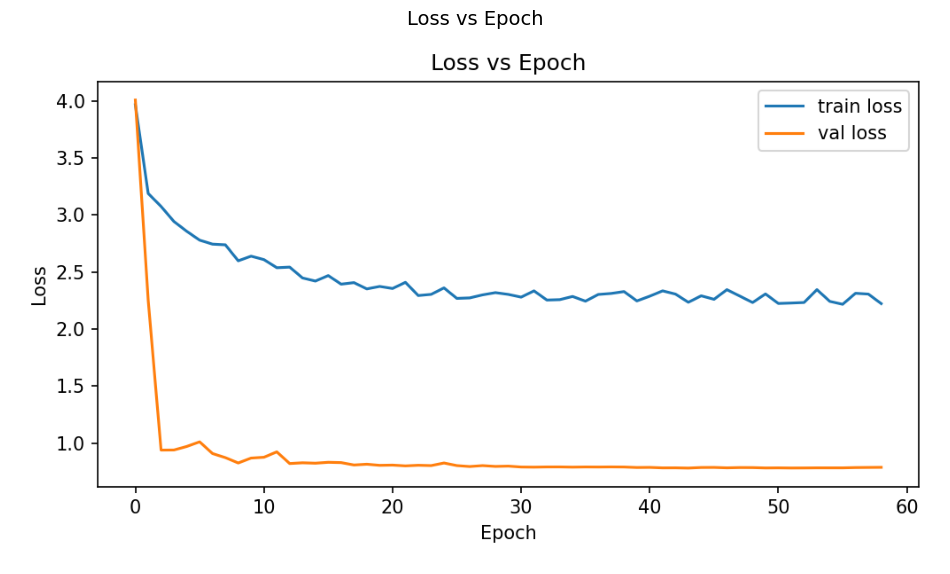

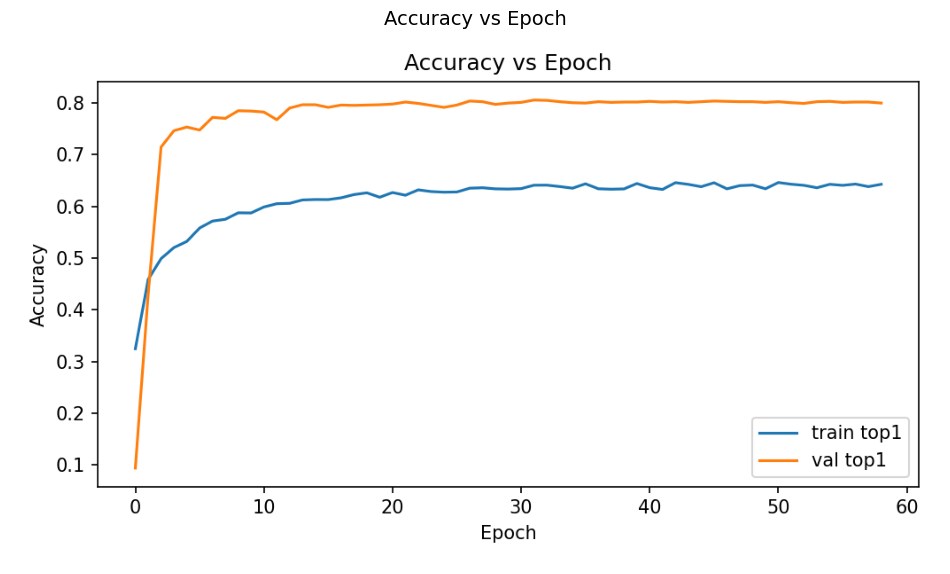

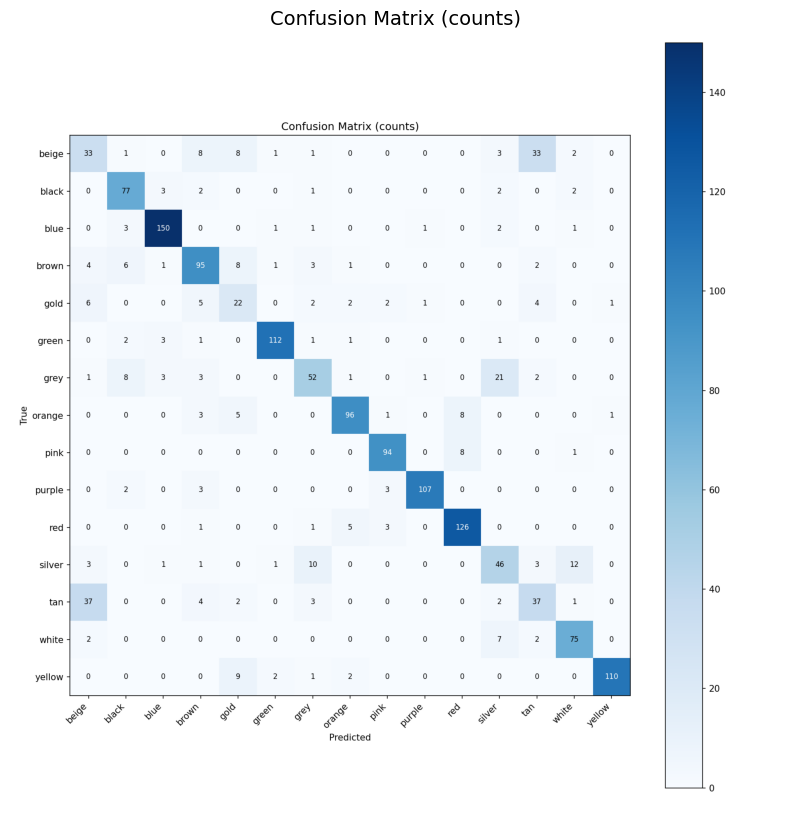

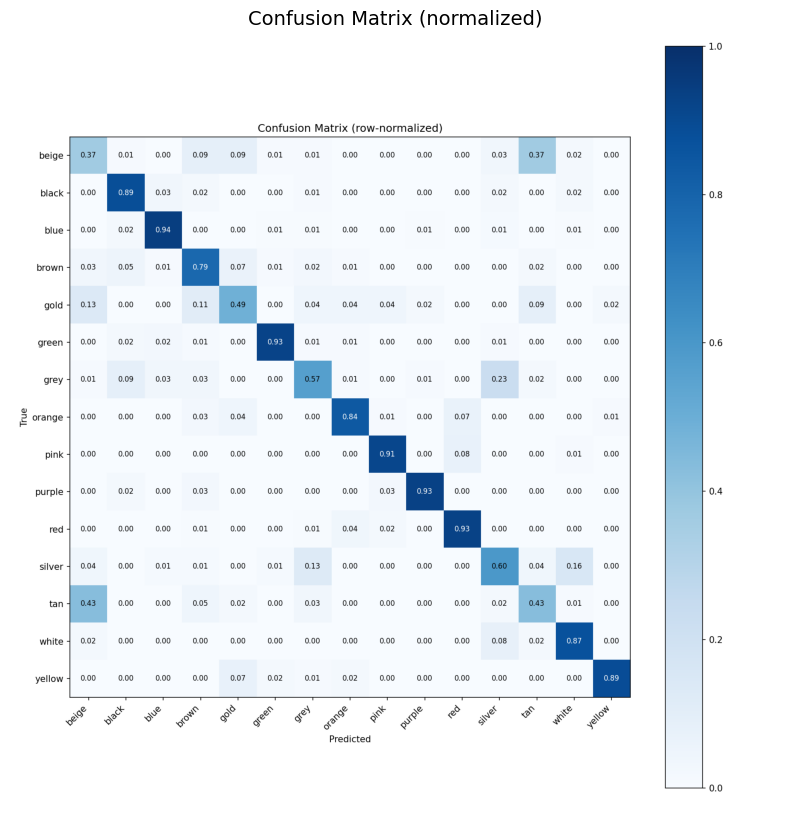

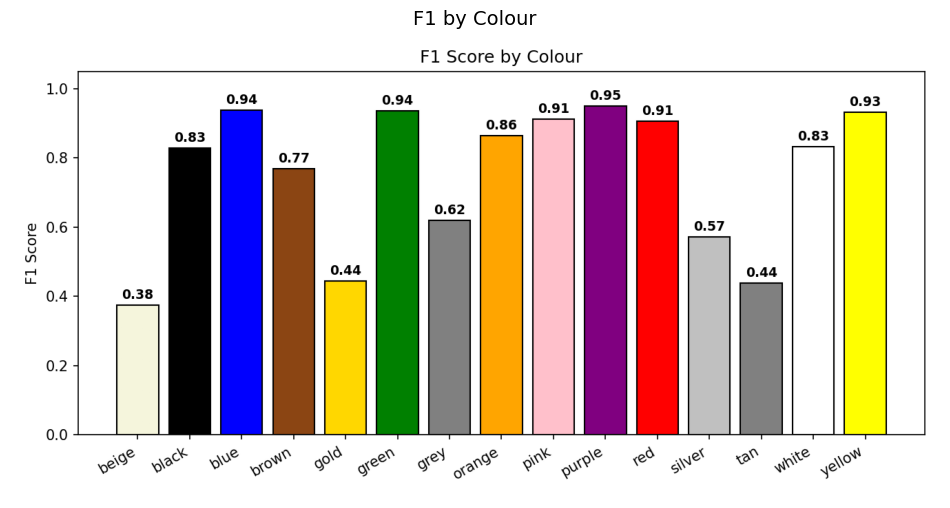

In [87]:
# plot files
plots = [
    ("Loss vs Epoch", "curve_loss_vs_epoch.png"),
    ("Accuracy vs Epoch", "curve_accuracy_vs_epoch.png"),
    ("Confusion Matrix (counts)", "confusion_matrix_counts.png"),
    ("Confusion Matrix (normalized)", "confusion_matrix_normalized.png"),
    ("F1 by Colour", "f1_by_colour.png"),
]

for title, fname in plots:
    path = OUTPUT_DIR / fname
    if path.exists():
        img = plt.imread(path)
        plt.figure(figsize=(12, 10))
        plt.imshow(img)
        plt.axis("off")
        plt.title(title, fontsize=14)
        plt.show()
    else:
        print(f"[Skip] {fname} not found.")